<a href="https://colab.research.google.com/github/BenGreenleaf/Helios/blob/main/helios_pressure_budget.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Feed system pressure budget — 20 bar, confirmed components

In [1]:
import numpy as np
import matplotlib.pyplot as plt


**Confirmed component data** (Ham-Let H-700 ball valve, Swagelok SS-1VS8 needle valve, Swagelok SS-8C-10 check valve).

In [2]:
gamma = 1.405
M = 2.016e-3
Ru = 8.314
R = Ru / M
T0 = 293.0

Cv_ball, Cv_needle, Cv_check = 9.25, 0.73, 1.68
Kv_ball, Kv_needle, Kv_check = Cv_ball*0.865, Cv_needle*0.865, Cv_check*0.865
P_crack_check = 0.69   # bar, SS-8C-10 fixed cracking pressure

print(f"Kv: ball={Kv_ball:.3f}, needle={Kv_needle:.3f}, check={Kv_check:.3f} m3/h")
print(f"Check valve cracking pressure = {P_crack_check} bar (acts as a floor on its dP)")


Kv: ball=8.001, needle=0.631, check=1.453 m3/h
Check valve cracking pressure = 0.69 bar (acts as a floor on its dP)


**ISA gas-valve relation** (constant 514, sanity-checked against the Rev-1 CDR's own worked numbers at 8.4 bar).

In [3]:
def isa_dP_bar(mdot_gs, Kv, Pavg_bar_abs, T1=293.0, Gg=0.0696, C=514.0):
    rho_std = 101325 / (R * 273.15)
    mdot_kgh = mdot_gs / 1000 * 3600
    Qn = mdot_kgh / rho_std
    return (Qn**2 * Gg * T1) / (C**2 * Kv**2 * Pavg_bar_abs), Qn

dP_chk_old, _ = isa_dP_bar(5.22, 1.68*0.865, 8.4, T1=300.0)
print(f"Sanity check (expect ~0.20 bar): {dP_chk_old:.3f} bar")


Sanity check (expect ~0.20 bar): 0.194 bar


**Pipework**: Darcy-Weisbach over ~4 m of 1/2in Sched 40S tube (matches BOM tube quantity), plus an allowance for the 2 elbows/2 connectors/1 union.

In [4]:
D_bore = 0.0158
A_pipe = np.pi/4*D_bore**2
mu_H2 = 8.9e-6

def pipe_dP_bar(mdot_gs, P_bar_abs, L=4.0, K_fittings=1.5):
    rho = (P_bar_abs*1e5)/(R*T0)
    V = (mdot_gs/1000)/(rho*A_pipe)
    Re = rho*V*D_bore/mu_H2
    f = 0.316/Re**0.25 if Re < 1e5 else 0.184/Re**0.2
    dP = (f*(L/D_bore) + K_fittings) * (rho*V**2/2)
    return dP/1e5, V, Re


**Injector choke threshold** (from the orifice-sizing notebook — 3.4 mm orifice, P3 = 3.5 bar abs).

In [5]:
d_nom = 3.4
Cd = 0.55
GAMMA = np.sqrt(gamma*(2/(gamma+1))**((gamma+1)/(gamma-1)))
crit_ratio = ((gamma+1)/2)**(gamma/(gamma-1))
P_inj_min = crit_ratio * 3.5

def required_P0_bar_abs(mdot_gs, d_mm=d_nom, T0=T0, Cd=Cd):
    A = np.pi*(d_mm/2e3)**2
    return (mdot_gs/1e3)*np.sqrt(R*T0)/(Cd*A*GAMMA)/1e5

print(f"P_inj,min (choke threshold) = {P_inj_min:.2f} bar abs")


P_inj,min (choke threshold) = 6.64 bar abs


**Full budget walk**, in the confirmed P&ID order (ball valve -> pipework -> needle valve [active] -> check valve -> injector).
Check valve dP is taken as max(cracking pressure, ISA result) — the cracking pressure is the dominant term here, not the Cv-only estimate.

In [6]:
P_feed = 20.0  # bar abs

rows = []
for mdot in [3.0, 4.5, 6.0]:
    dP_ball, *_ = isa_dP_bar(mdot, Kv_ball, P_feed)
    dP_pipe, V, Re = pipe_dP_bar(mdot, P_feed)
    P_before_needle = P_feed - dP_ball - dP_pipe

    P_inj_req = required_P0_bar_abs(mdot)
    dP_check_isa, _ = isa_dP_bar(mdot, Kv_check, P_inj_req + 0.5)
    dP_check = max(P_crack_check, dP_check_isa)
    P_needle_outlet = P_inj_req + dP_check
    dP_needle = P_before_needle - P_needle_outlet

    margin = P_inj_req / P_inj_min
    rows.append((mdot, dP_ball, dP_pipe, P_before_needle, dP_needle, dP_check, P_inj_req, margin))

print(f"{'mdot':<6}{'ball dP':<10}{'pipe dP':<10}{'@needle in':<12}{'needle dP':<12}{'check dP':<10}{'P_inj':<9}{'margin'}")
for r in rows:
    print(f"{r[0]:<6}{r[1]:<10.4f}{r[2]:<10.4f}{r[3]:<12.2f}{r[4]:<12.2f}{r[5]:<10.3f}{r[6]:<9.2f}x{r[7]:.2f}")


mdot  ball dP   pipe dP   @needle in  needle dP   check dP  P_inj    margin
3.0   0.0009    0.0055    19.99       9.67        0.690     9.63     x1.45
4.5   0.0020    0.0113    19.99       4.85        0.690     14.45    x2.18
6.0   0.0035    0.0191    19.98       0.02        0.690     19.27    x2.90


**Plot — pressure available at each stage vs mass flow.**

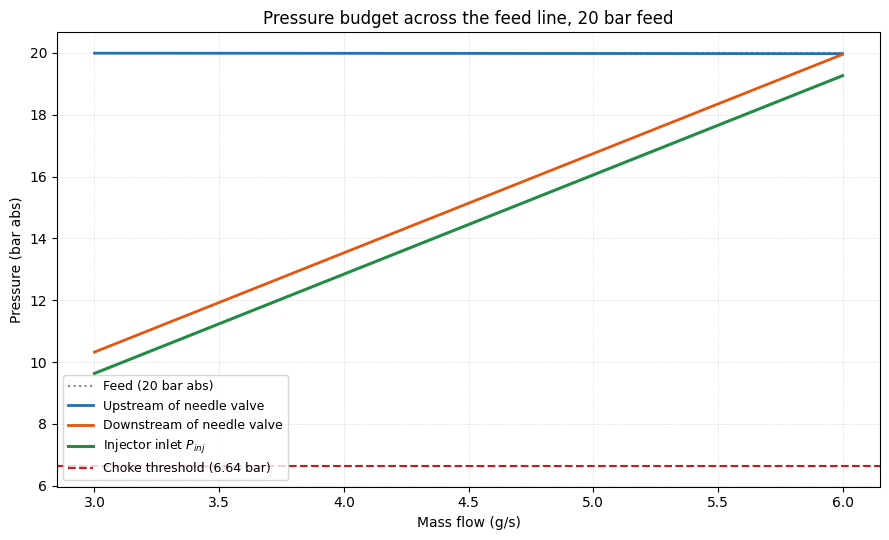

In [7]:
m_sweep = np.linspace(3.0, 6.0, 60)
P_needle_in, P_needle_out, P_inj_arr = [], [], []
for mdot in m_sweep:
    dP_ball, *_ = isa_dP_bar(mdot, Kv_ball, P_feed)
    dP_pipe, *_ = pipe_dP_bar(mdot, P_feed)
    p_ni = P_feed - dP_ball - dP_pipe
    p_inj = required_P0_bar_abs(mdot)
    dP_check_isa, _ = isa_dP_bar(mdot, Kv_check, p_inj + 0.5)
    dP_check = max(P_crack_check, dP_check_isa)
    P_needle_in.append(p_ni)
    P_needle_out.append(p_inj + dP_check)
    P_inj_arr.append(p_inj)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(m_sweep, [P_feed]*len(m_sweep), color='#888', linewidth=1.5, linestyle=':', label='Feed (20 bar abs)')
ax.plot(m_sweep, P_needle_in, color='#2171b5', linewidth=2, label='Upstream of needle valve')
ax.plot(m_sweep, P_needle_out, color='#e6550d', linewidth=2, label='Downstream of needle valve')
ax.plot(m_sweep, P_inj_arr, color='#238b45', linewidth=2.2, label='Injector inlet $P_{inj}$')
ax.axhline(P_inj_min, color='#cb181d', linewidth=1.5, linestyle='--', label=f'Choke threshold ({P_inj_min:.2f} bar)')
ax.set_xlabel('Mass flow (g/s)'); ax.set_ylabel('Pressure (bar abs)')
ax.set_title('Pressure budget across the feed line, 20 bar feed')
ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.5); ax.legend(fontsize=9, loc='lower left')
plt.tight_layout(); plt.savefig('pressure_budget.png', dpi=150, bbox_inches='tight'); plt.show()


**Summary.**

In [8]:
worst = min(r[7] for r in rows)
print(f"Fixed losses (ball valve + pipework + check valve) stay under ~1 bar across 3-6 g/s")
print(f"Needle valve carries the rest of the throttling: {rows[0][4]:.1f} bar at 3 g/s down to {rows[-1][4]:.1f} bar at 6 g/s")
print(f"Worst-case choke margin: x{worst:.2f}")


Fixed losses (ball valve + pipework + check valve) stay under ~1 bar across 3-6 g/s
Needle valve carries the rest of the throttling: 9.7 bar at 3 g/s down to 0.0 bar at 6 g/s
Worst-case choke margin: x1.45
